# EDA — Flight Delay Classification

Exploratory analysis of the cleaned flights dataset (106 444 rows × 38 columns).  
The target is **DELAY_CATEGORY** with 4 classes: `on_time`, `minor_delay`, `major_delay`, `cancelled`.

### 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", None)

PALETTE = {"on_time": "#4CAF50", "minor_delay": "#FFEA2E",
           "major_delay": "#ED9512", "cancelled": "#EE4B2B"}
CAT_ORDER = ["on_time", "minor_delay", "major_delay", "cancelled"]

In [ ]:
df = pd.read_csv("../data/processed/flights_cleaned.csv")
print(f"shape: {df.shape}\n")
print(f"columns: {df.columns}")

shape: (106444, 38)

columns: Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME',
       'DISTANCE', 'SCHEDULED_ARRIVAL', 'DIVERTED', 'CANCELLATION_REASON',
       'departure_hour', 'scheduled_arrival_hour', 'temperature_c',
       'precipitation_mm', 'rain_mm', 'snowfall_cm', 'wind_speed_kmh',
       'wind_direction_deg', 'wind_gusts_kmh', 'cloud_cover_pct',
       'weather_code', 'relative_humidity_pct', 'pressure_msl_hpa',
       'dest_temperature_c', 'dest_precipitation_mm', 'dest_rain_mm',
       'dest_snowfall_cm', 'dest_wind_speed_kmh', 'dest_wind_direction_deg',
       'dest_wind_gusts_kmh', 'dest_cloud_cover_pct', 'dest_weather_code',
       'dest_relative_humidity_pct', 'dest_pressure_msl_hpa',
       'DELAY_CATEGORY'],
      dtype='object')


### 2. Dataset Overview

In [ ]:
def sample_values(series, n=3):
    vals = series.dropna().astype(str).unique()[:n]
    return ", ".join(vals) if len(vals) else "(all missing)"

schema_rows = []
for col in df.columns:
    schema_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "non_null": int(df[col].notna().sum()),
        "null_pct": round(df[col].isna().mean() * 100, 2),
        "n_unique": int(df[col].nunique(dropna=True)),
        "sample_values": sample_values(df[col], n=3),
    })

schema_overview = pd.DataFrame(schema_rows).reset_index(drop=True)
schema_overview

,column,dtype,non_null,null_pct,n_unique,sample_values
0,YEAR,int64,106444,0.00,1,2015
1,MONTH,int64,106444,0.00,11,"1, 2, 3"
2,DAY,int64,106444,0.00,31,"6, 14, 11"
3,DAY_OF_WEEK,int64,106444,0.00,7,"2, 3, 7"
4,AIRLINE,object,106444,0.00,14,"WN, OO, EV"
5,ORIGIN_AIRPORT,object,106444,0.00,315,"BNA, OAK, ATL"
6,DESTINATION_AIRPORT,object,106444,0.00,316,"DAL, BUR, ORD"
7,SCHEDULED_DEPARTURE,int64,106444,0.00,1211,"805, 1045, 1955"
8,SCHEDULED_TIME,float64,106444,0.00,333,"130.0, 65.0, 125.0"
9,DISTANCE,int64,106444,0.00,1227,"623, 325, 606"


In [ ]:
special_feats = ["CANCELLATION_REASON", "DIVERTED"]

time_features = ["MONTH", "DAY_OF_WEEK", "departure_hour", "scheduled_arrival_hour"]

cat_features = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

num_features = ["SCHEDULED_TIME", "DISTANCE"]

weather_features = [
    "temperature_c", "precipitation_mm", "rain_mm", "snowfall_cm",
    "wind_speed_kmh", "wind_gusts_kmh", "cloud_cover_pct",
    "relative_humidity_pct", "pressure_msl_hpa"
]

dest_weather_features = [
    "dest_temperature_c", "dest_precipitation_mm", "dest_rain_mm", "dest_snowfall_cm",
    "dest_wind_speed_kmh", "dest_wind_gusts_kmh", "dest_cloud_cover_pct",
    "dest_relative_humidity_pct", "dest_pressure_msl_hpa"
]

target = "DELAY_CATEGORY"

**Key observations:**
- The dataset spans a single year (2015) with months 1–9, 11–12 (October is missing).
- `CANCELLATION_REASON` is 98.4 % null — only populated for the 1 719 cancelled flights.
- `YEAR` has only 1 unique value (2015) and provides no predictive information.
- `weather_code` / `dest_weather_code` are **categorical** codes stored as floats (WMO codes: 0 = clear, 1–3 = fog/haze, 51–55 = drizzle, 61–65 = rain, 71–75 = snow). They should be encoded as categories, not used as numeric.
- `wind_direction_deg` is a **circular** variable (0° = 360°) and should not be treated as a regular numeric feature — use sin/cos encoding.
- Origin and destination weather columns mirror each other and may show multicollinearity.

### 3. Target Distribution

In [ ]:
counts = df[target].value_counts().reindex(CAT_ORDER)
perc = (counts / counts.sum() * 100).round(2)
dist = pd.DataFrame({"count": counts, "percentage": perc})
dist

,count,percentage
DELAY_CATEGORY,,
on_time,85673,80.49
minor_delay,10703,10.06
major_delay,8349,7.84
cancelled,1719,1.61


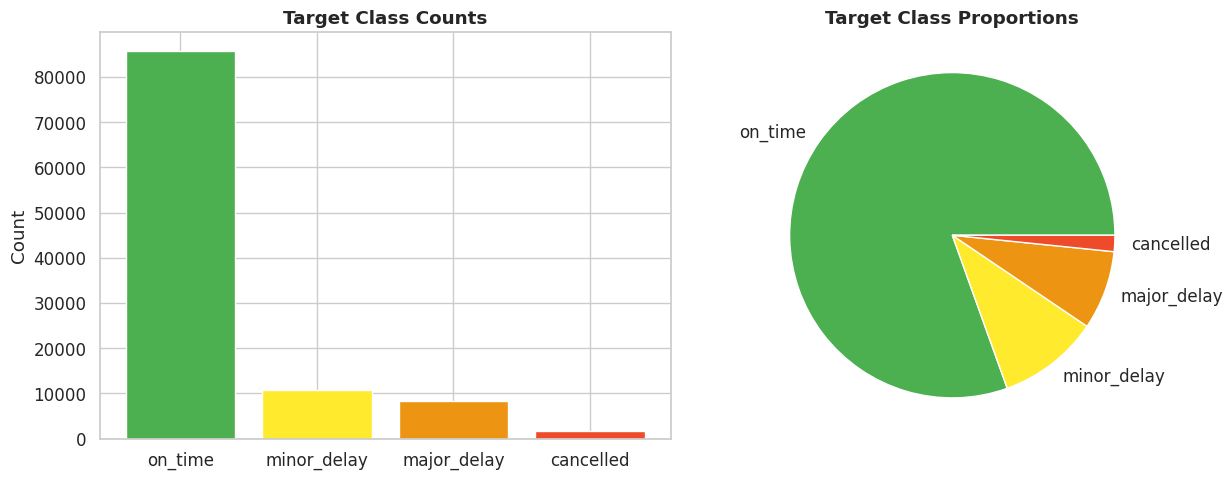

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(CAT_ORDER, counts.values,
              color=[PALETTE[c] for c in CAT_ORDER])
ax.set_title("Target Class Counts", fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")

ax = axes[1]
ax.pie(counts.values, labels=CAT_ORDER,
       colors=[PALETTE[c] for c in CAT_ORDER])
ax.set_title("Target Class Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

**Interpretation:**
- The dataset is **severely imbalanced**: on_time flights dominate at ~80.5 %, while cancelled flights represent only ~1.6 %
- Minor and major delays together account for ~18 % of flights.
- **Action needed:** Use class weighting or sampling techniquee during modelling.
- Accuracy is a misleading metric here

### 4. Univariate Analysis

#### 4a. Numerical Features — Histograms

In [ ]:
def batch_histogram(df, cols, batch_size=6, n_cols=2):
    cols = [c for c in cols if c in df.columns]
    for start in range(0, len(cols), batch_size):
        batch = cols[start:start + batch_size]
        n_rows = int(np.ceil(len(batch) / n_cols))
        _, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = np.array(axes).reshape(-1)
        for i, col in enumerate(batch):
            ax = axes[i]
            s = df[col].dropna()
            q01, q99 = s.quantile([0.01, 0.99])
            s_plot = s[(s >= q01) & (s <= q99)]
            ax.hist(s_plot, bins=30)
            ax.set_title(col, fontweight="bold")
        plt.tight_layout()
        plt.show()

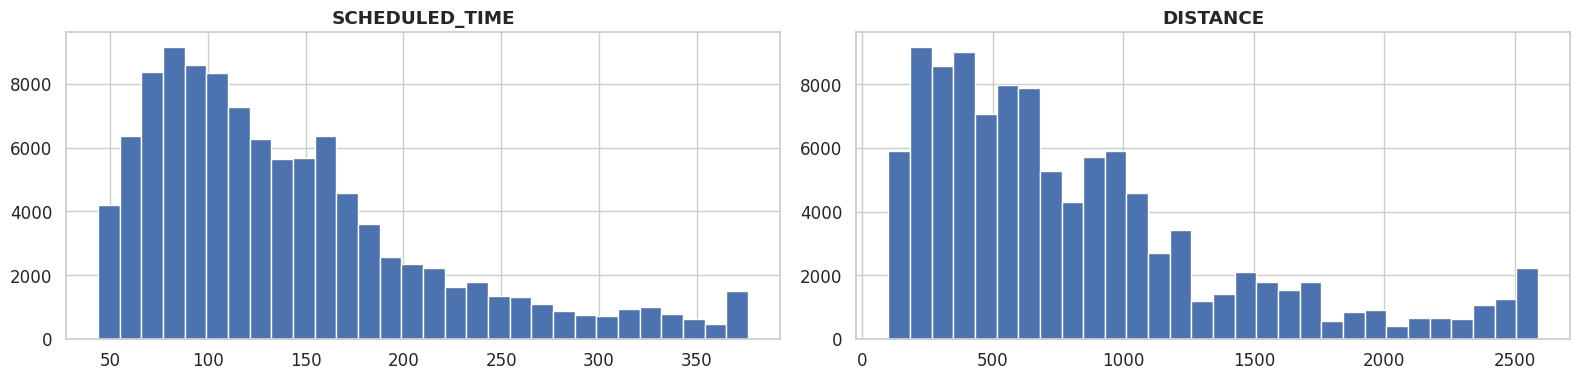

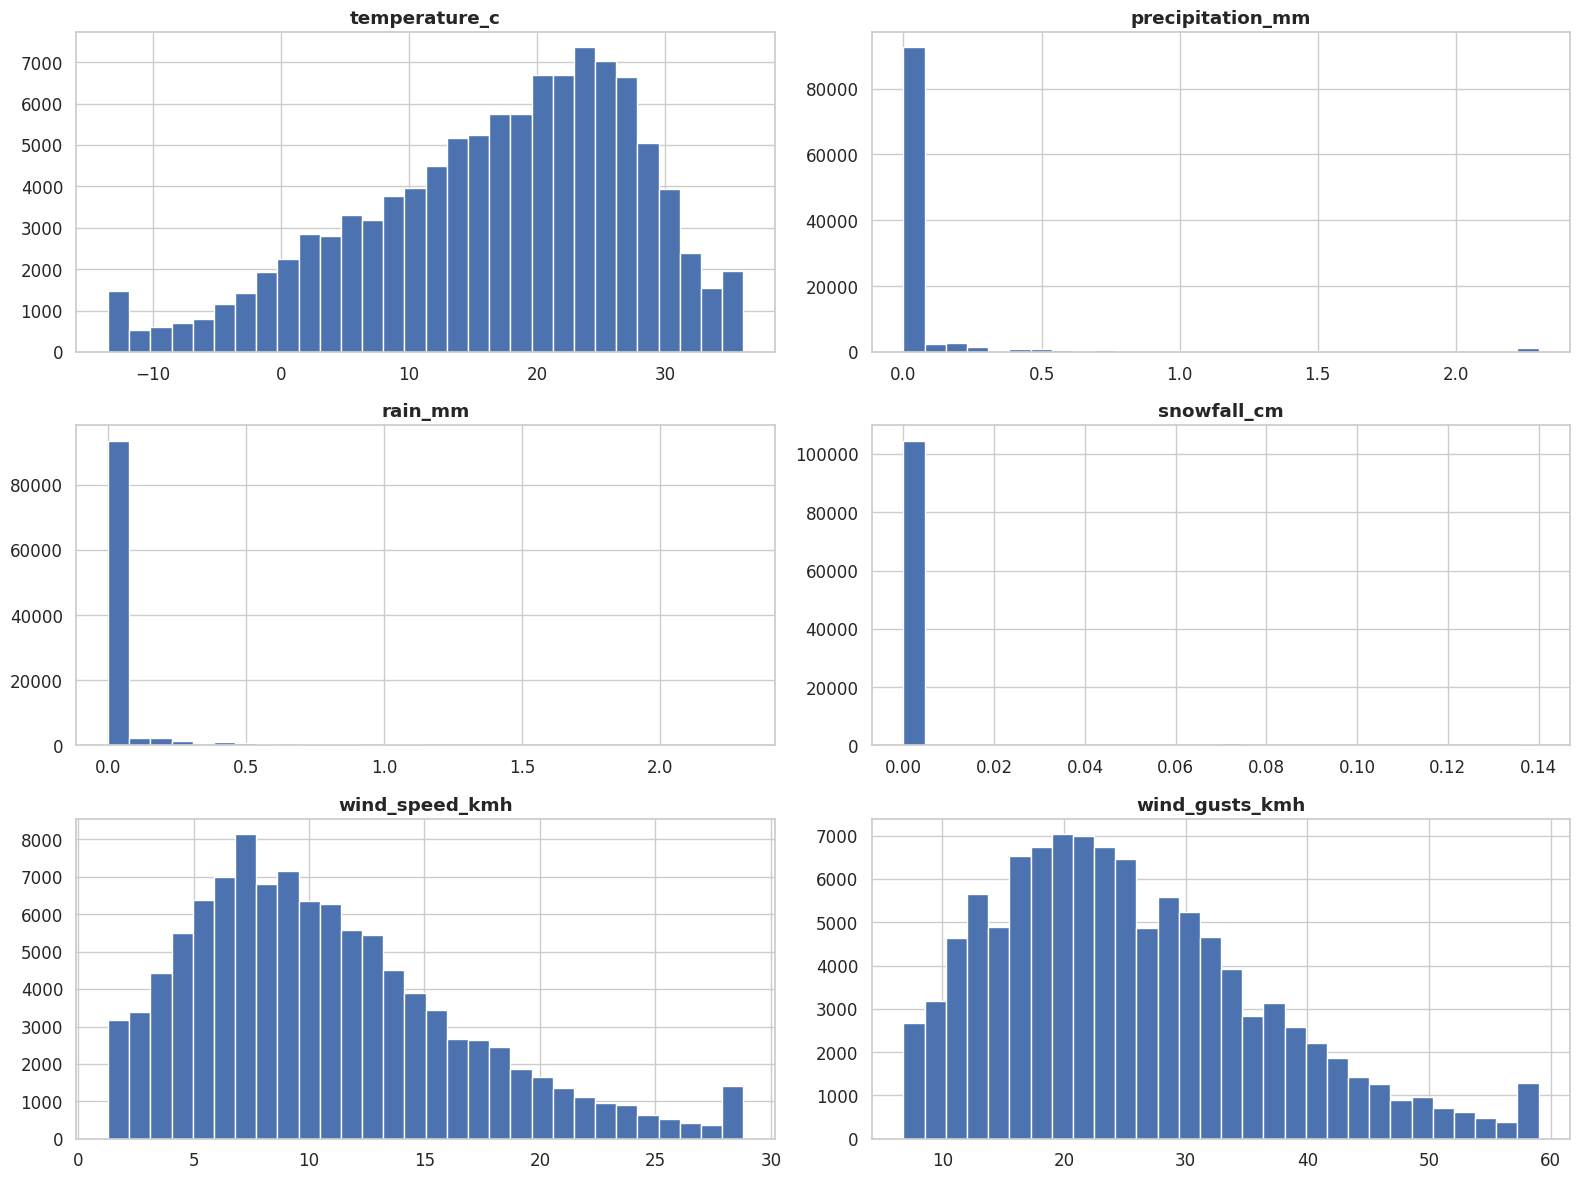

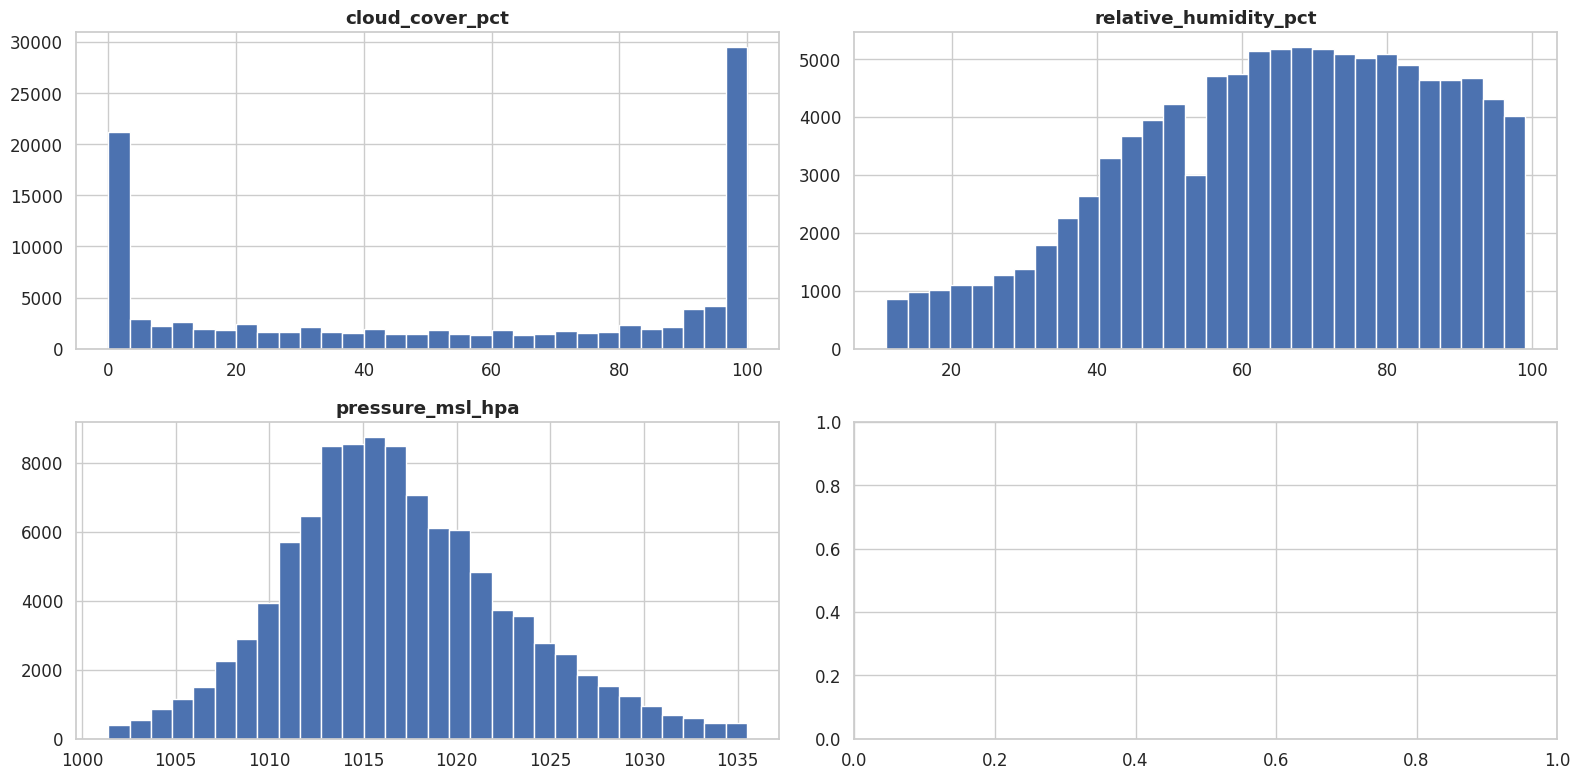

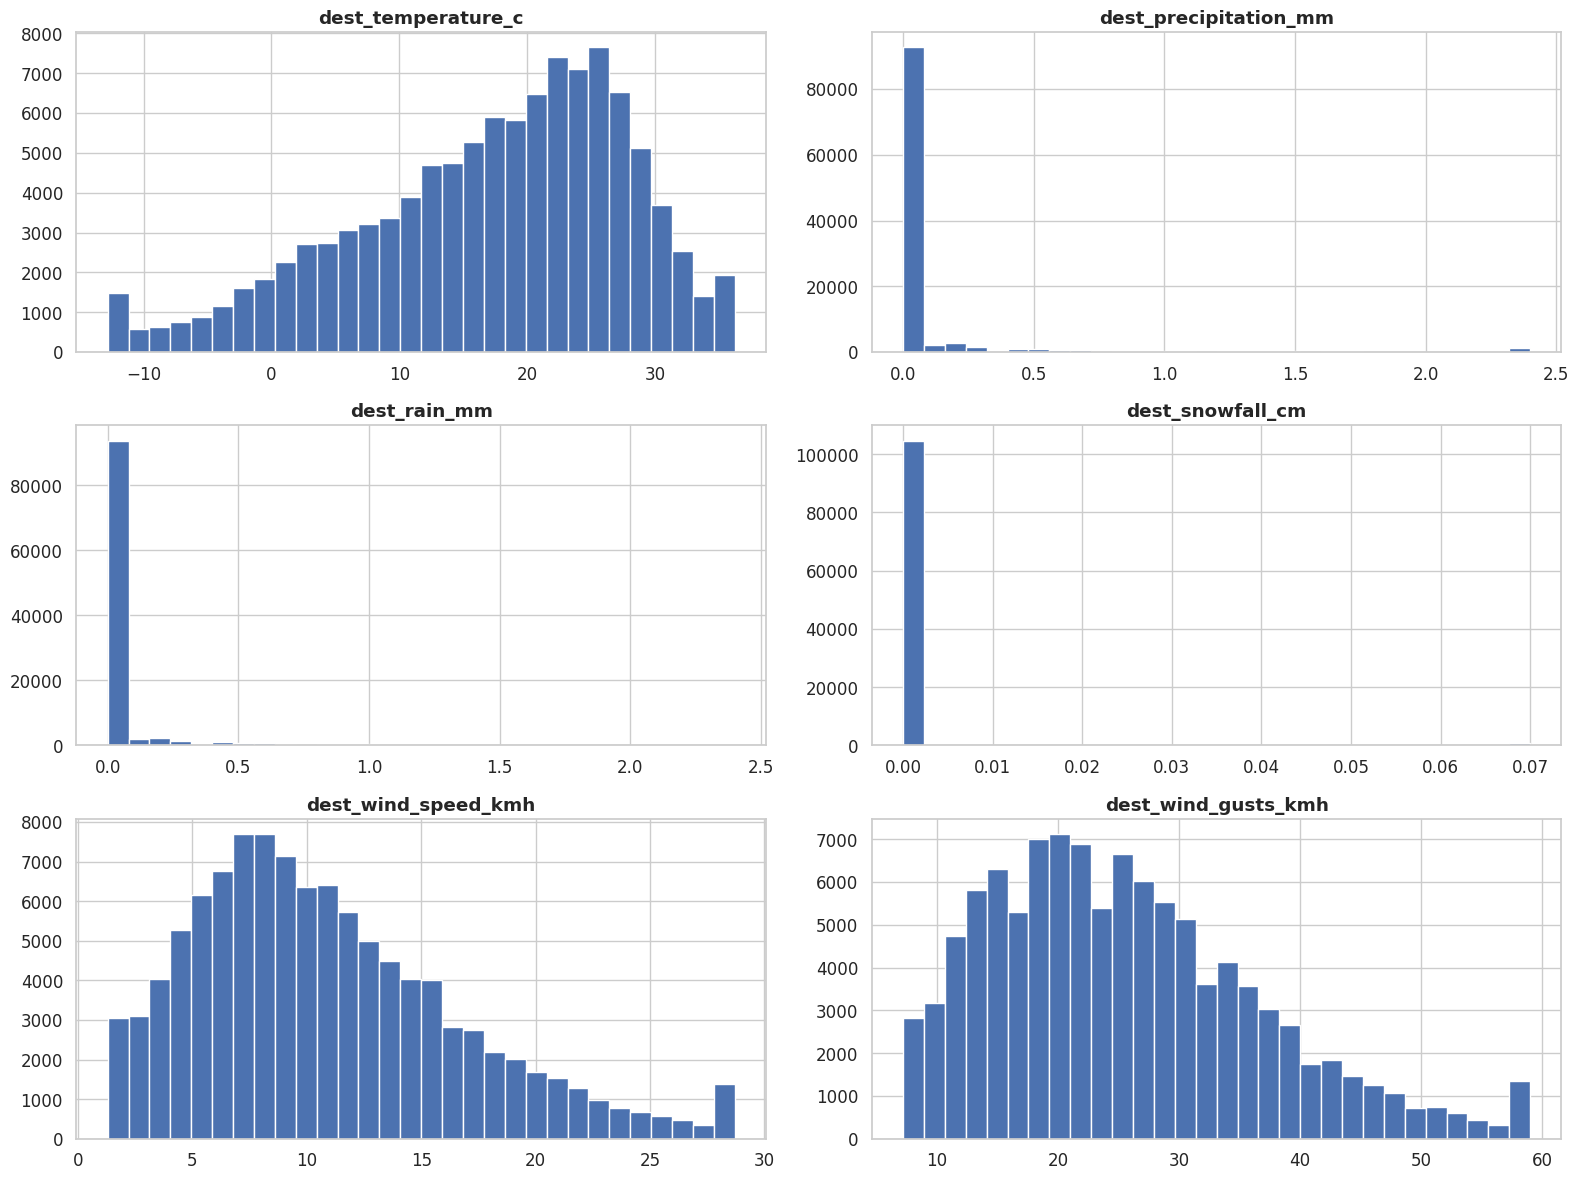

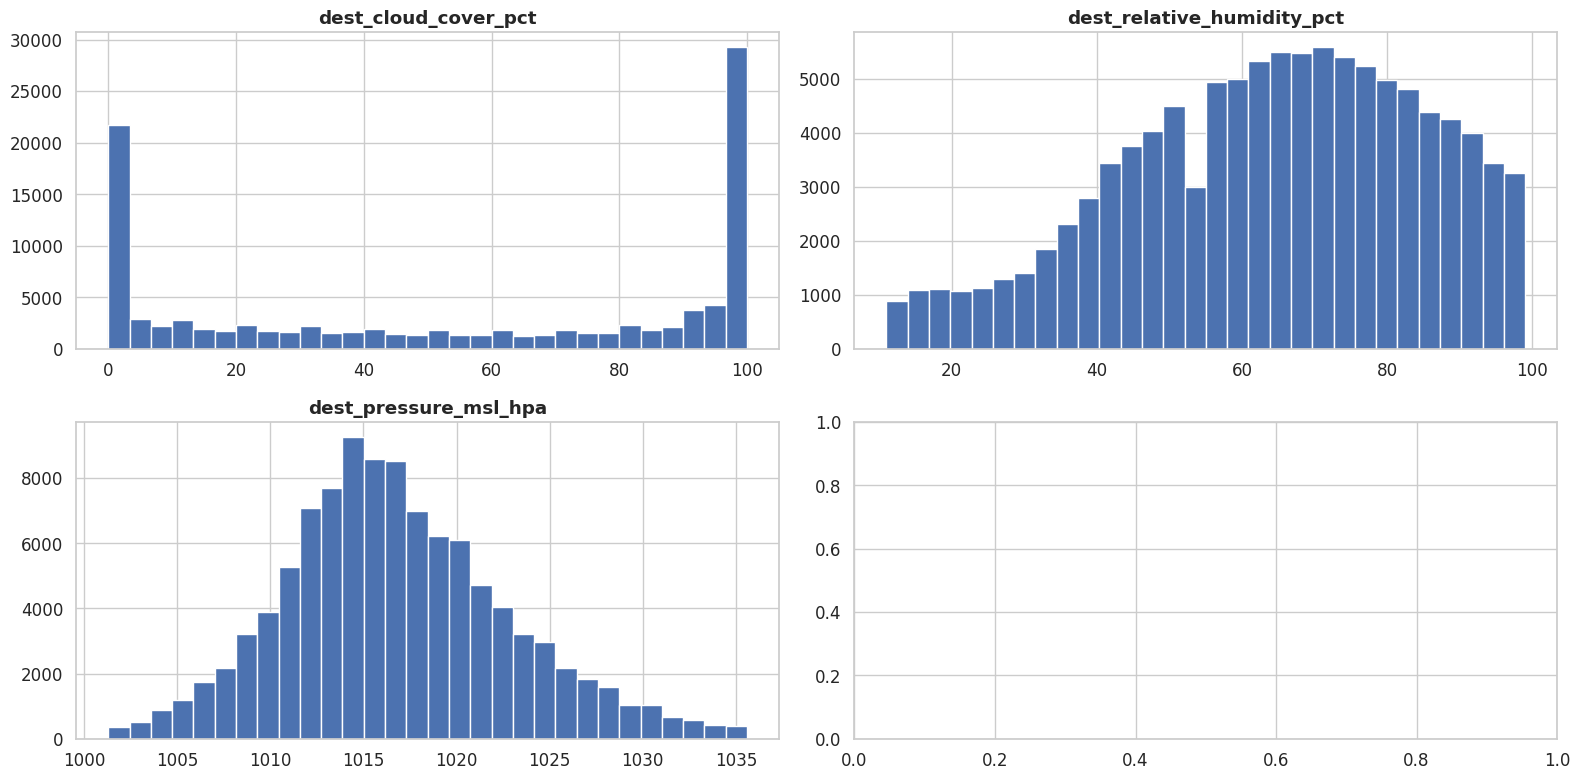

In [ ]:
batch_histogram(df, num_features, batch_size=4, n_cols=2)
batch_histogram(df, weather_features, batch_size=6, n_cols=2)
batch_histogram(df, dest_weather_features, batch_size=6, n_cols=2)

**Interpretation:**
- `SCHEDULED_TIME` and `DISTANCE` are right-skewed — most flights are short
- `precipitation_mm`, `rain_mm`, `snowfall_cm` most flights experience none of these so we can treat them as binary instead of continuous ig?
- `wind_speed_kmh` and `wind_gusts_kmh` are right-skewed.
- `cloud_cover_pct` U-shape distribution flights tend to experience either clear (0 %) or cloudy (100 %) skies, with some few coverage with other values.
- `pressure_msl_hpa` is normally distributed
- Destination weather features mirror origin features in distribution shape, which is expected since the same airports appear in both roles.

#### 4b. Categorical Features — Bar Plots

In [ ]:
def batch_barplot(df, cols, top_n=8, batch_size=3):
    cols = [c for c in cols if c in df.columns]
    for start in range(0, len(cols), batch_size):
        batch = cols[start:start + batch_size]
        fig, axes = plt.subplots(len(batch), 1,
                                 figsize=(14, 5 * len(batch)))
        if len(batch) == 1:
            axes = [axes]
        for i, col in enumerate(batch):
            ax = axes[i]
            top = df[col].value_counts().nlargest(top_n)
            sns.barplot(x=top.index.astype(str), y=top.values, ax=ax,
                        color="#5C6BC0")
            ax.set_title(f"{col}", fontweight="bold")
            ax.set_ylabel("Count")
            ax.set_xlabel(col)
        plt.tight_layout()
        plt.show()

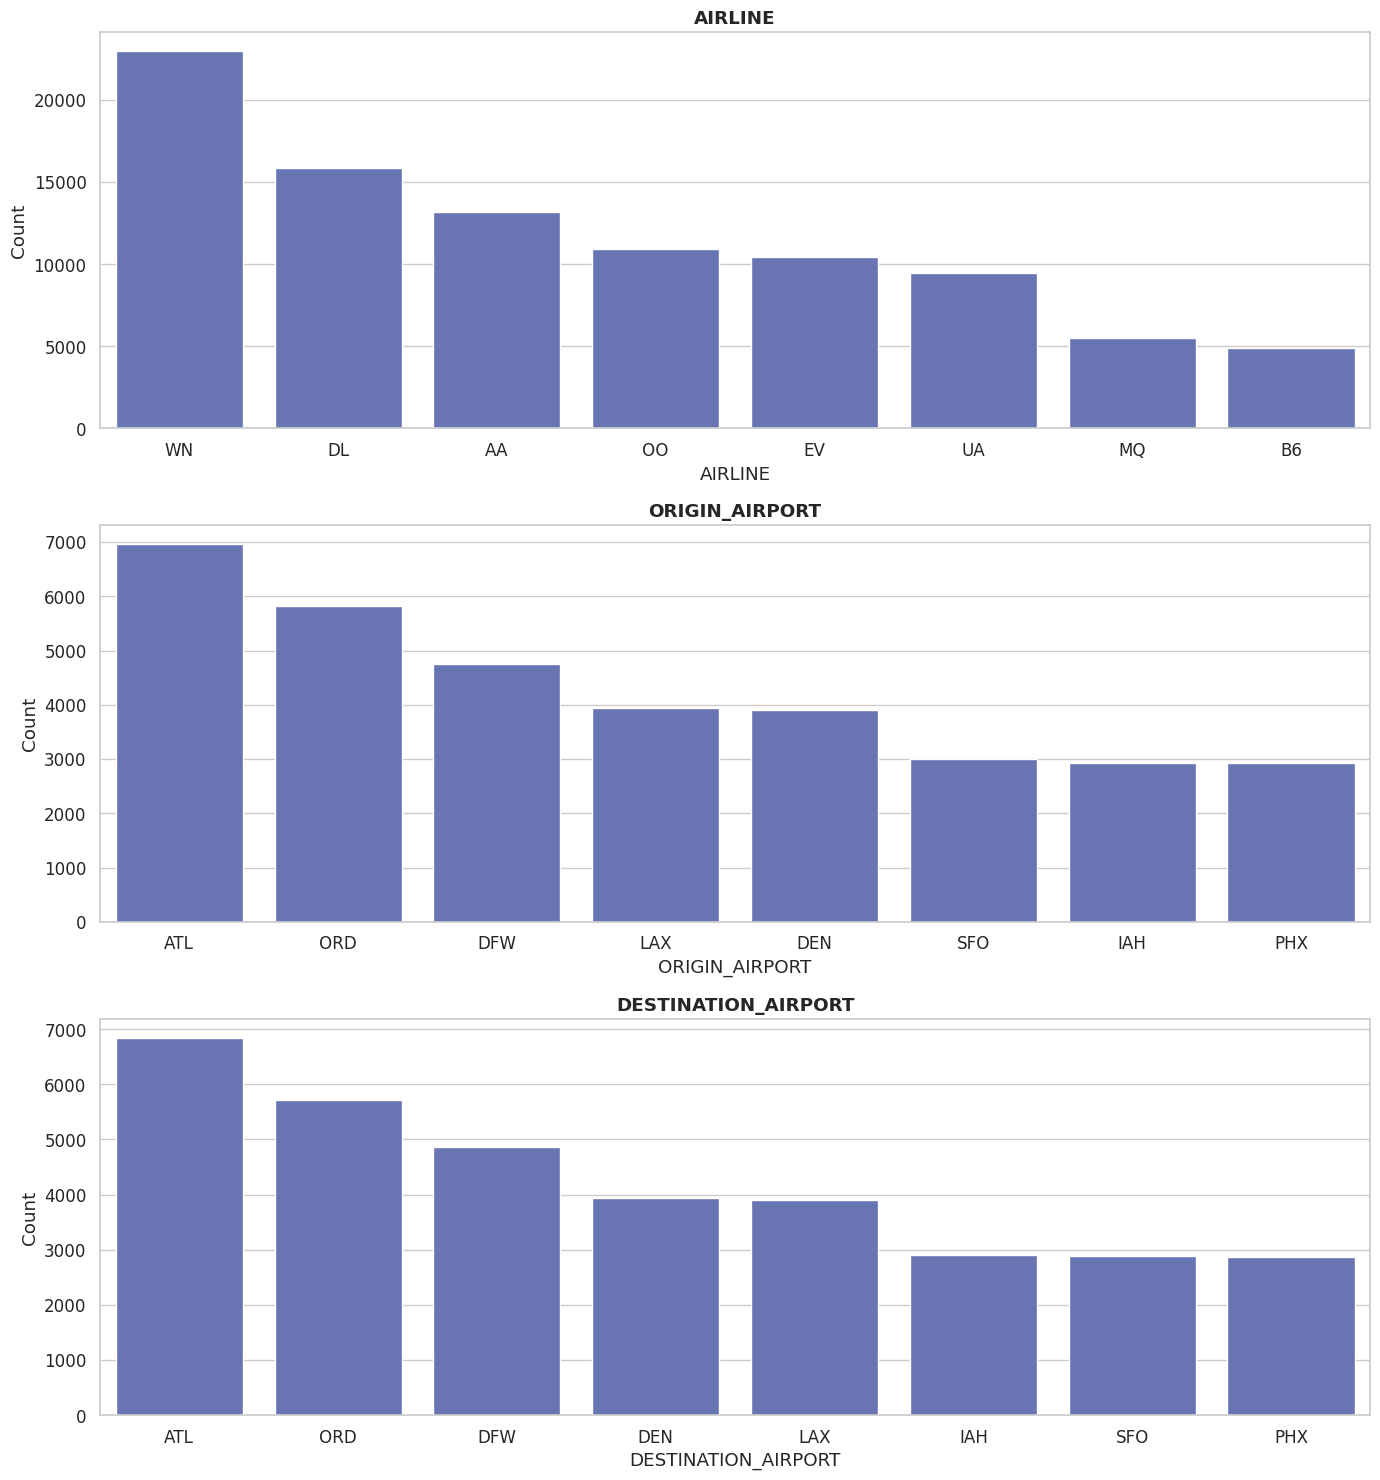

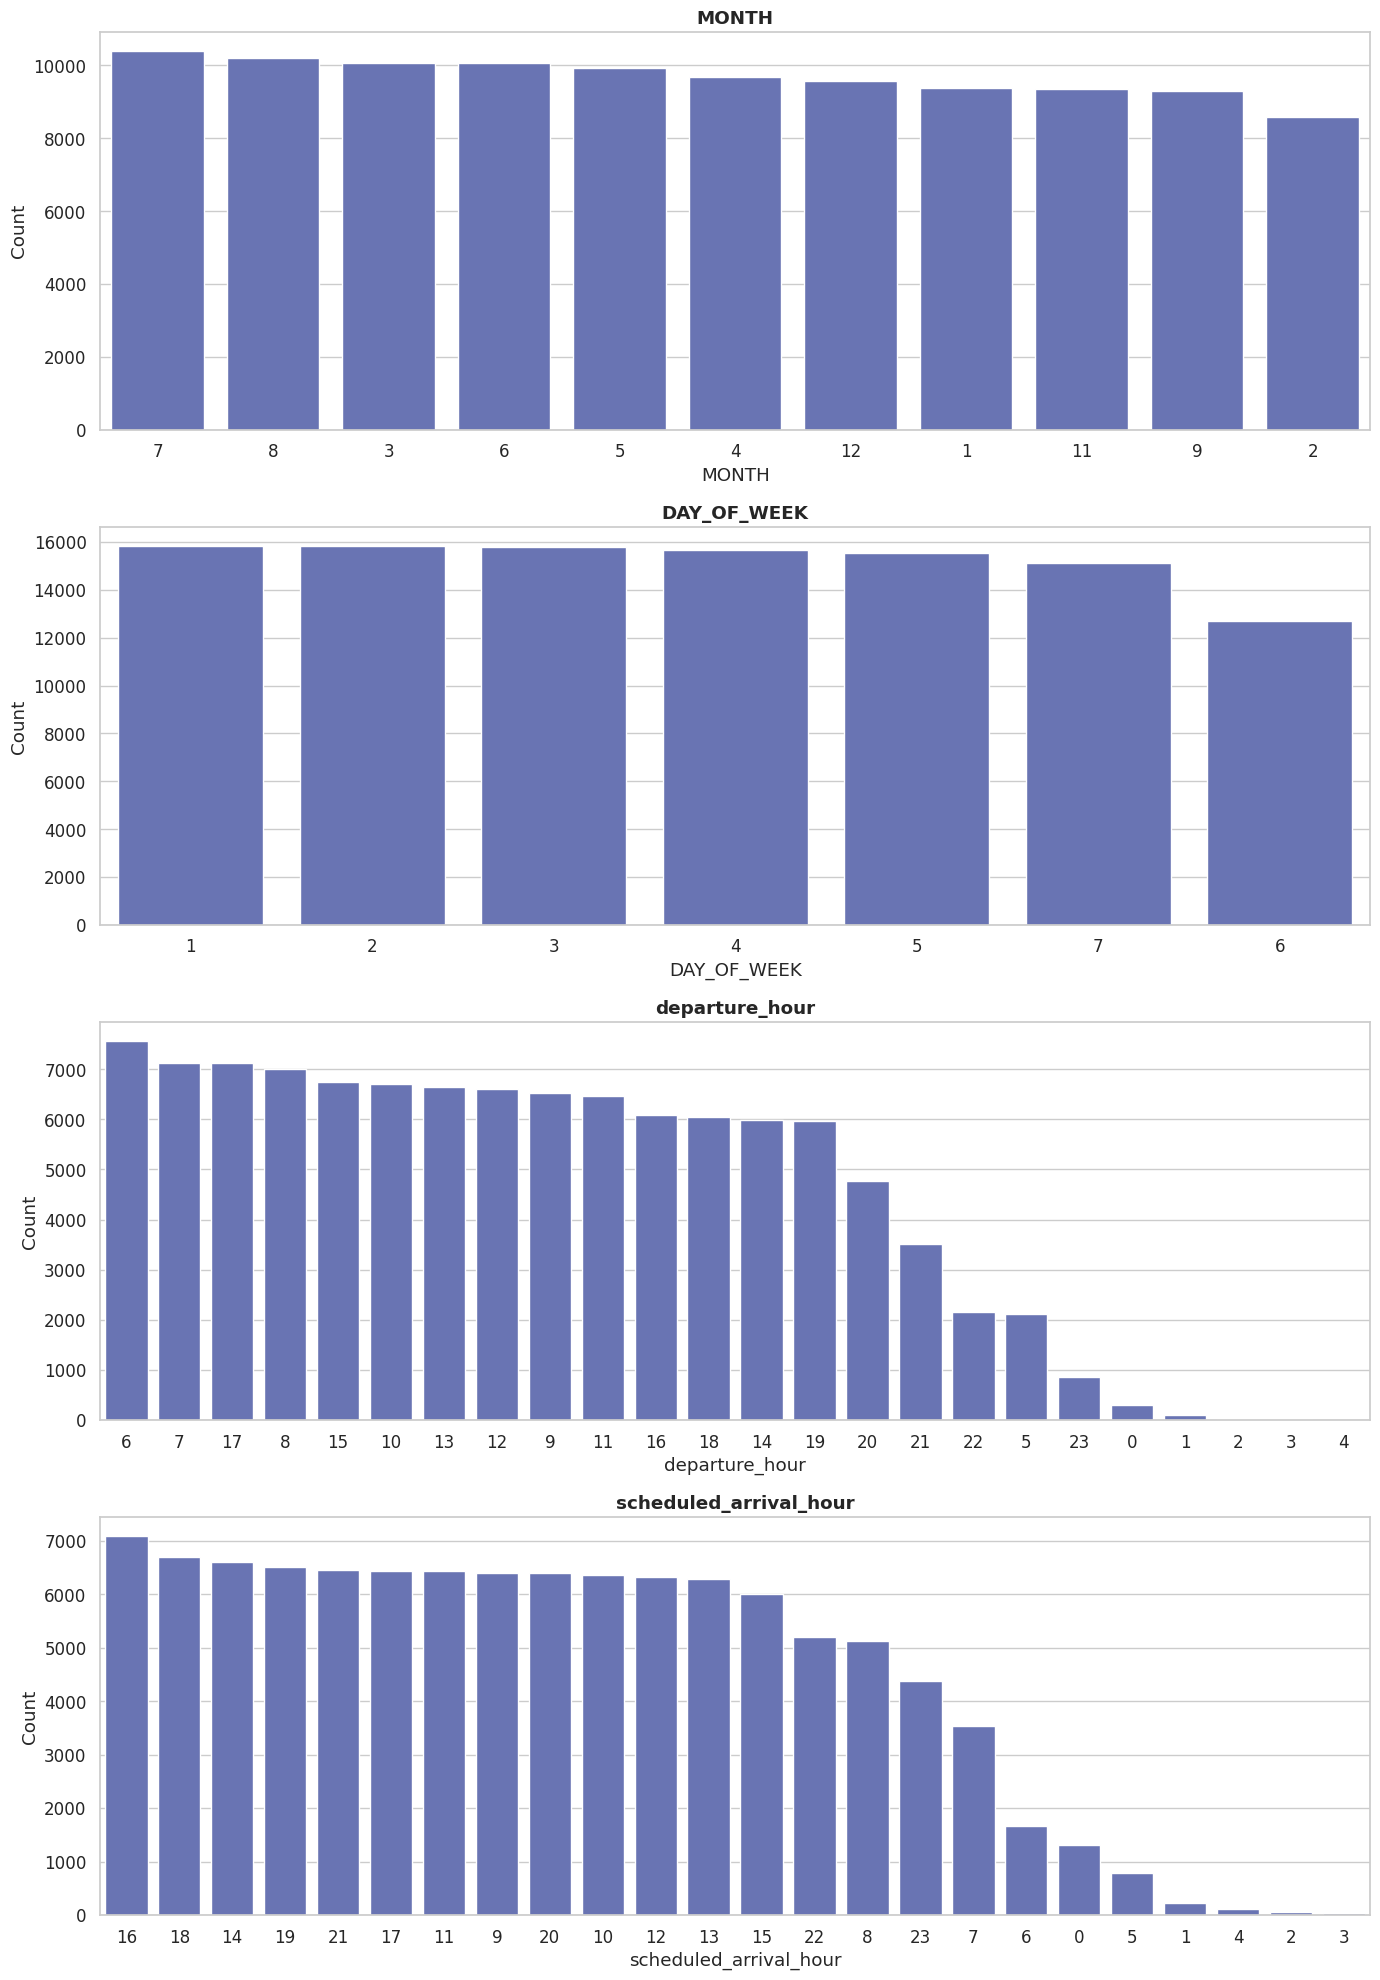

In [ ]:
batch_barplot(df, cat_features, top_n = 8)
batch_barplot(df, time_features, top_n = 24, batch_size=4)

**Interpretation:**
- **Airlines:** WN (Southwest) is the dominant.
- **Airports:** ATL, ORD, DFW, DEN are the busiest origin/destination airports.
- **Months:** uniformly distributed -October is missing from the dataset-
- **Day of week:** Slightly fewer flights on Saturday (day 6) but they are all almost similar.
- **Departure hour:** Very few departures between 00:00–06:00.

#### 4c. Descriptive Statistics

In [ ]:
df[time_features + num_features + weather_features + dest_weather_features]\
  .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])\
  .T.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
MONTH,106444.0,6.21,3.38,1.0,1.0,1.00,3.0,6.0,9.0,12.0,12.00,12.00
DAY_OF_WEEK,106444.0,3.92,1.99,1.0,1.0,1.00,2.0,4.0,6.0,7.0,7.00,7.00
departure_hour,106444.0,13.02,4.84,0.0,5.0,6.00,9.0,13.0,17.0,21.0,22.00,23.00
scheduled_arrival_hour,106444.0,14.64,5.08,0.0,0.0,7.00,11.0,15.0,19.0,22.0,23.00,23.00
SCHEDULED_TIME,106444.0,141.90,73.96,44.0,44.0,59.00,86.0,124.0,175.0,309.0,376.00,376.00
DISTANCE,106444.0,823.07,596.39,100.0,100.0,172.15,373.0,651.0,1068.0,2248.0,2588.00,2588.00
temperature_c,106444.0,16.65,10.86,-13.5,-13.5,-3.48,9.6,18.5,25.0,31.5,36.10,36.10
precipitation_mm,106444.0,0.09,0.34,0.0,0.0,0.00,0.0,0.0,0.0,0.6,2.30,2.30
rain_mm,106444.0,0.10,0.49,0.0,0.0,0.00,0.0,0.0,0.0,0.5,2.30,15.50
snowfall_cm,106444.0,0.00,0.05,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.14,2.66


### 5. Bivariate Analysis — Feature vs Target

#### 5a. Numerical Features — Box Plots by Delay Category

In [ ]:
BOX_FEATURES = [
    "SCHEDULED_TIME", "DISTANCE",
    "temperature_c", "wind_speed_kmh", "wind_gusts_kmh",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "relative_humidity_pct", "cloud_cover_pct",
    "pressure_msl_hpa",
    "departure_hour", "scheduled_arrival_hour",
    "dest_temperature_c", "dest_wind_speed_kmh",
    "dest_wind_gusts_kmh", "dest_precipitation_mm",
    "dest_relative_humidity_pct", "dest_cloud_cover_pct",
    "dest_pressure_msl_hpa",
]

In [ ]:
def plot_box_bivariate(df, features, target, batch_size=4, ncols=2):
    features = [c for c in features if c in df.columns]
    for start in range(0, len(features), batch_size):
        batch = features[start:start + batch_size]
        nrows = int(np.ceil(len(batch) / ncols))
        _, axes = plt.subplots(nrows, ncols,
                                 figsize=(14, nrows * 3.5))
        axes = np.array(axes).flatten()
        for i, col in enumerate(batch):
            ax = axes[i]
            sns.boxplot(data=df, x=target, y=col, hue= target,
                        order=CAT_ORDER, palette=PALETTE, ax=ax)
            ax.set_title(f"{col} vs {target}", fontweight="bold")
            ax.set_ylabel(col)
        plt.suptitle(f"Bivariate Analysis: Features vs {target}",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

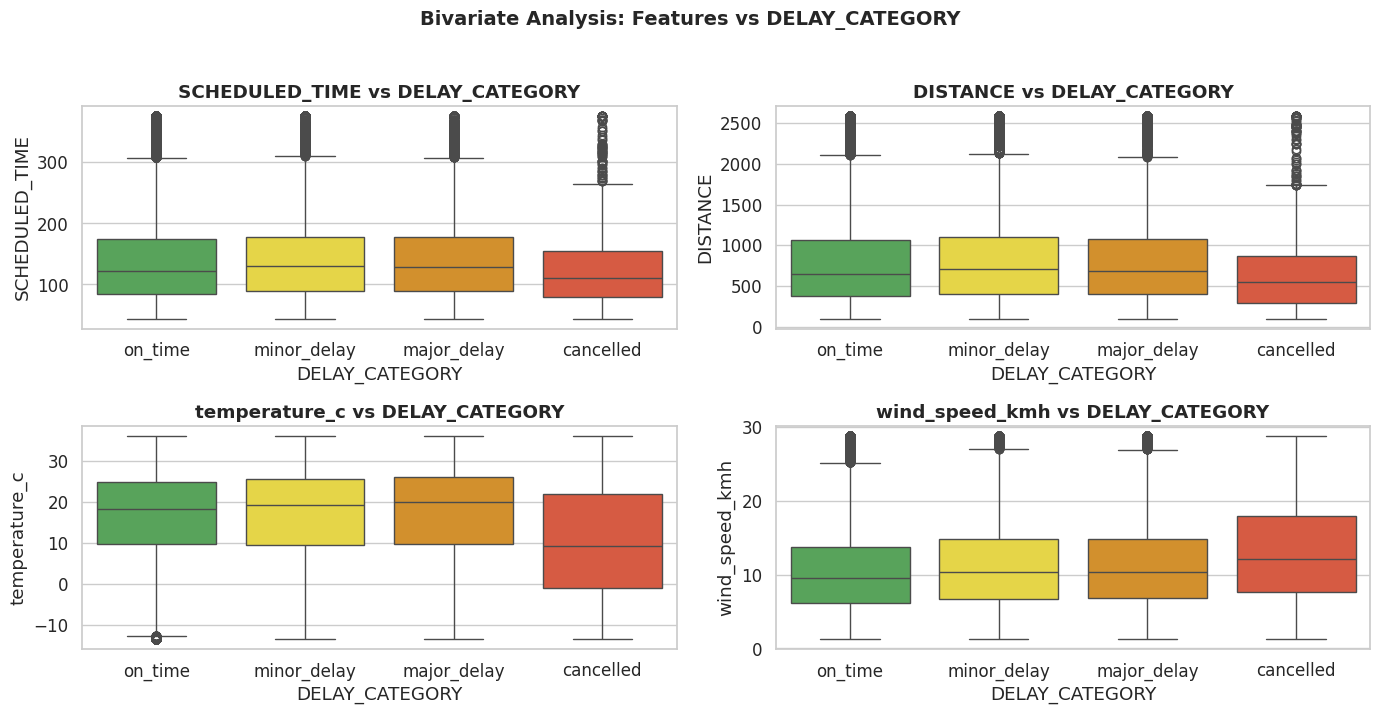

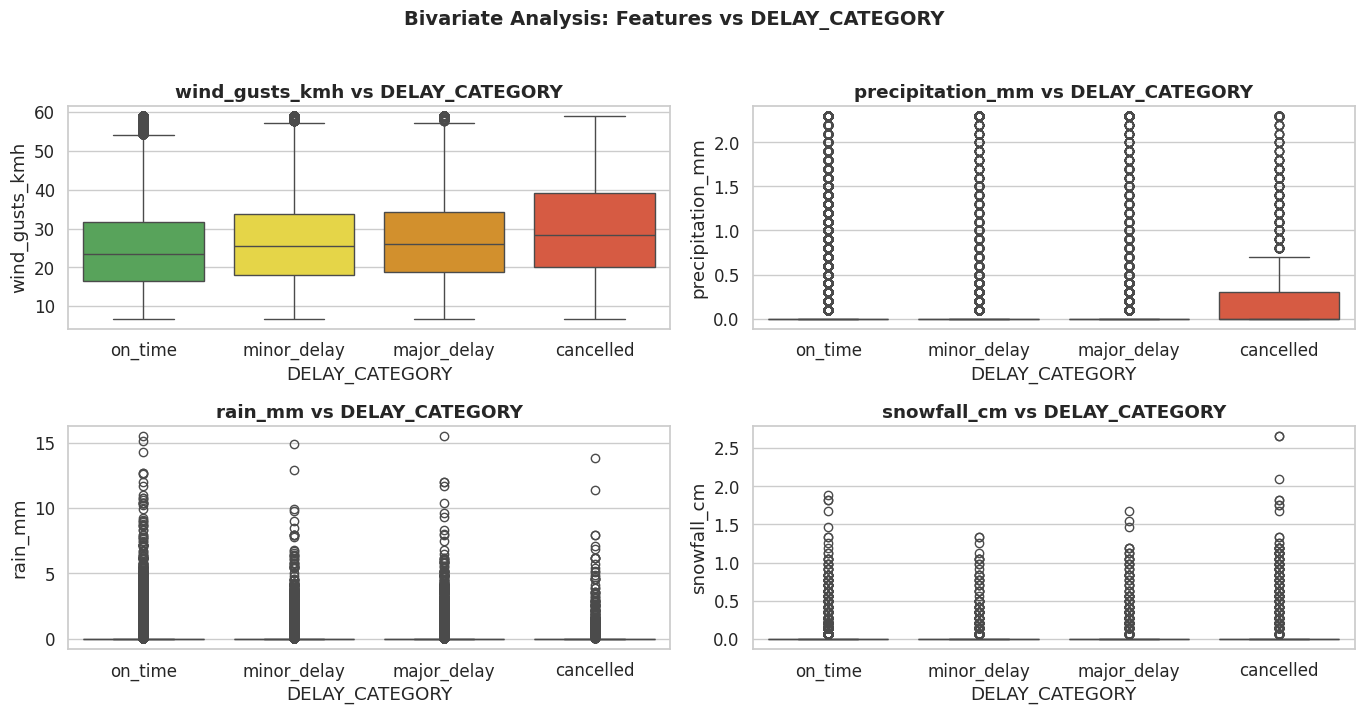

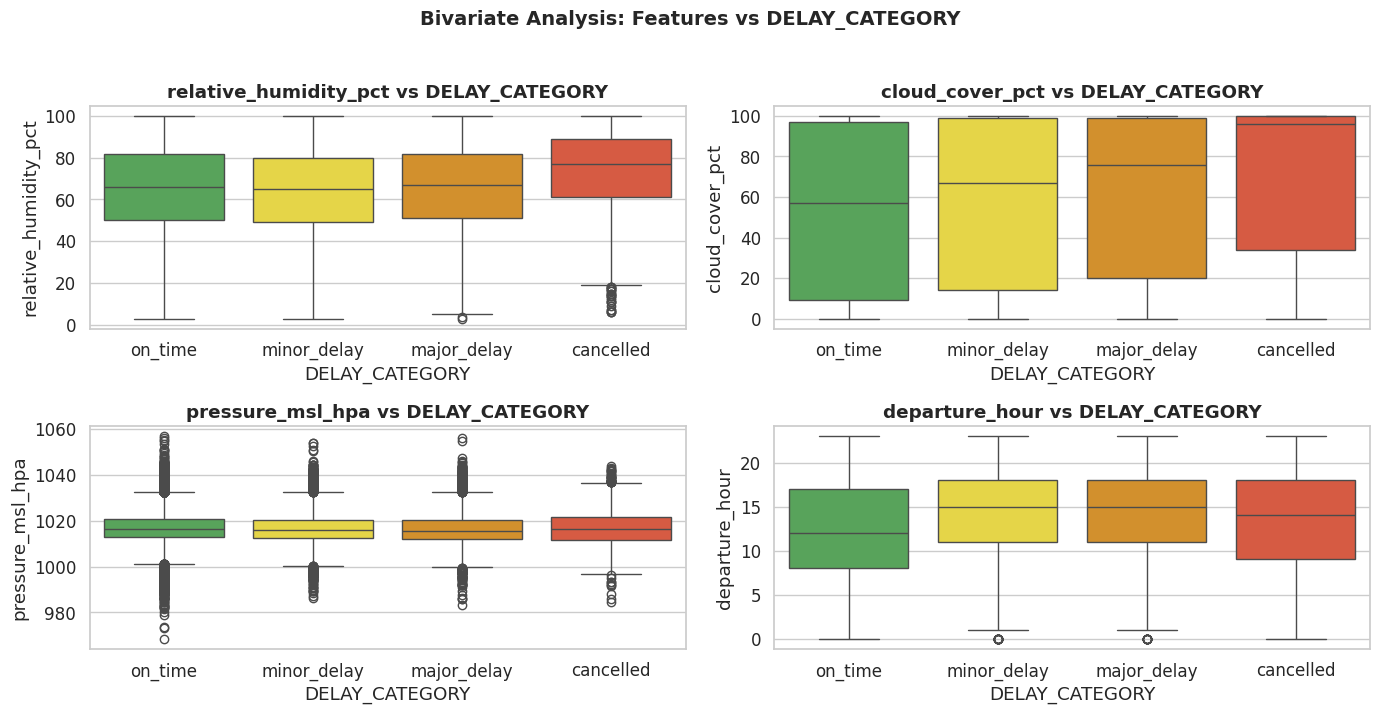

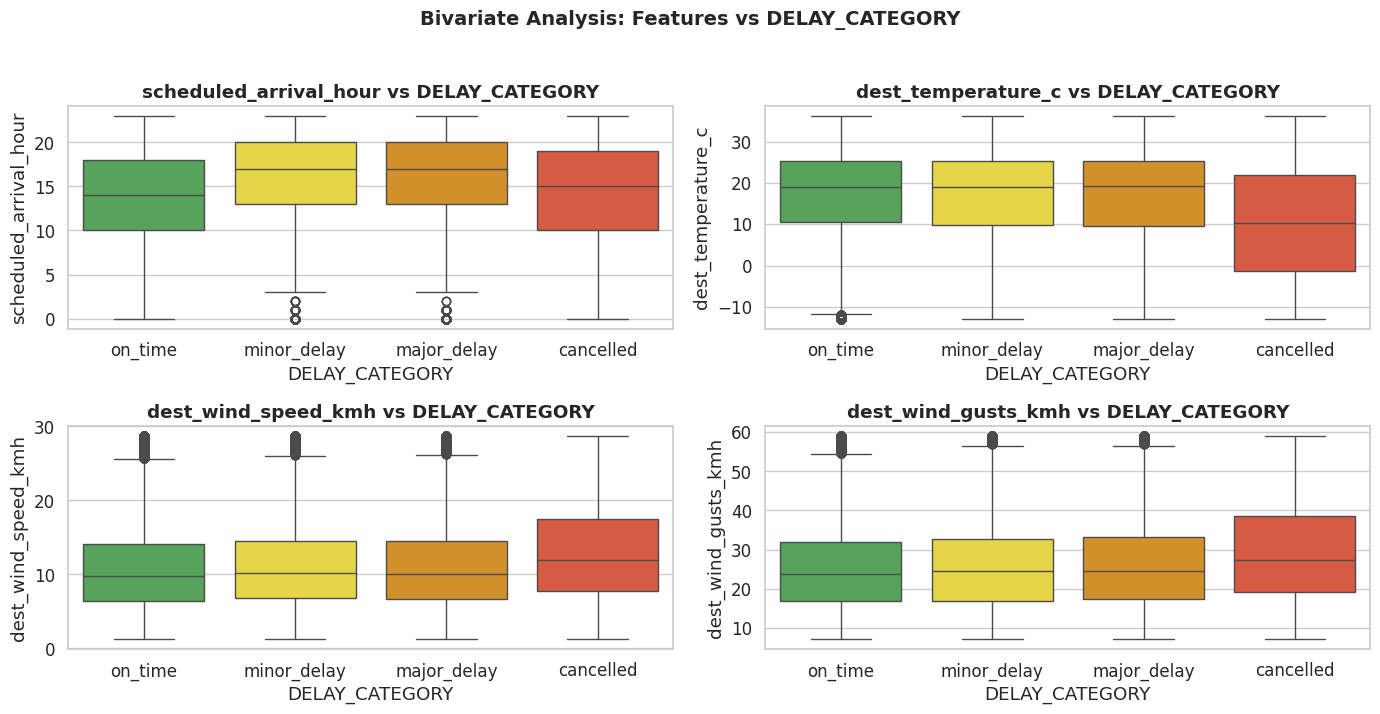

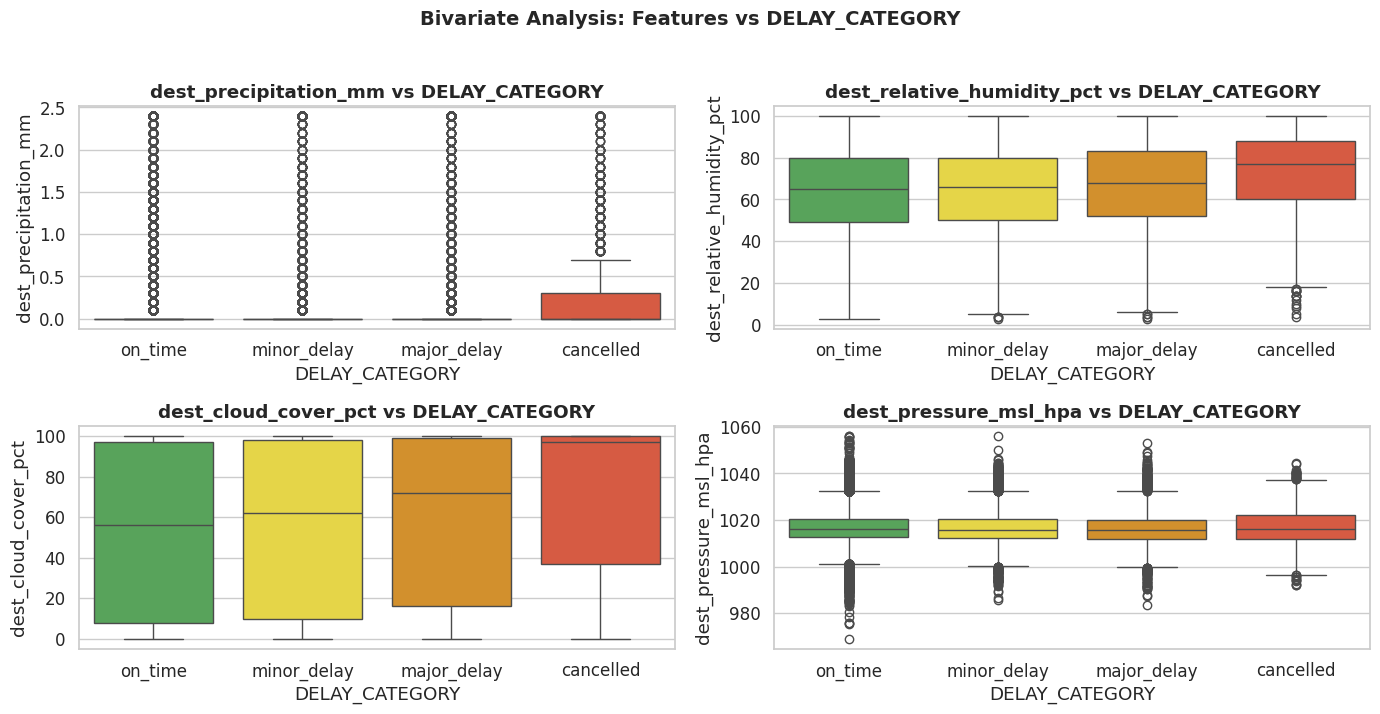

In [ ]:
plot_box_bivariate(df, BOX_FEATURES, target, batch_size=4, ncols=2)

**Interpretation:**
- `SCHEDULED_TIME` / `DISTANCE`: Cancelled and major-delay flights tend to have slightly longer scheduled times and distances — longer flights have more opportunity for delays to accumulate.
- `temperature_c`: Similar distributions across classes.
- `wind_speed_kmh` / `wind_gusts_kmh`: Cancelled flights show a slightly higher median wind speed/guts but most flights were in moderate wind so idk if it can be considered as a cencellation reason?
- `precipitation_mm` / `rain_mm` / `snowfall_cm`: almost all boxes are at zero due to zero-inflation. -shown earlier in the histograms section-
- `cloud_cover_pct`: higher cloud cover for cancelled/delayed flights.
- `departure_hour`: Delayed and cancelled flights depart at later hours on average (median around 15 for delayed/cancelled vs 12 for on-time). So mostly evening flights are more prone to delay propagation.

#### 5b. Categorical Features — Delay Rate by Category

Raw counts are misleading because on_time flights dominate so instead i will plot the proportion of each delay category within every group.

In [ ]:
def plot_cat_proportion(df, features, target, top_n=12, batch_size=3):
    features = [c for c in features if c in df.columns]
    for start in range(0, len(features), batch_size):
        batch = features[start:start + batch_size]
        _, axes = plt.subplots(len(batch), 1,
                                 figsize=(14, 5 * len(batch)))
        if len(batch) == 1:
            axes = [axes]
        for i, col in enumerate(batch):
            ax = axes[i]
            top = df[col].value_counts().nlargest(top_n).index
            subset = df[df[col].isin(top)]
            ct = pd.crosstab(subset[col], subset[target], normalize="index")
            ct = ct.reindex(columns=CAT_ORDER)
            ct = ct.reset_index().melt(id_vars=col,
                                       var_name=target,
                                       value_name="proportion")
            sns.barplot(data=ct, x=col, y="proportion",
                        hue=target, hue_order=CAT_ORDER,
                        palette=PALETTE, ax=ax)
            ax.set_title(f"Delay Proportion by {col}", fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Proportion")
            ax.tick_params(axis='x', rotation=45)
            ax.legend(title=target, fontsize=9)
        plt.tight_layout()
        plt.show()

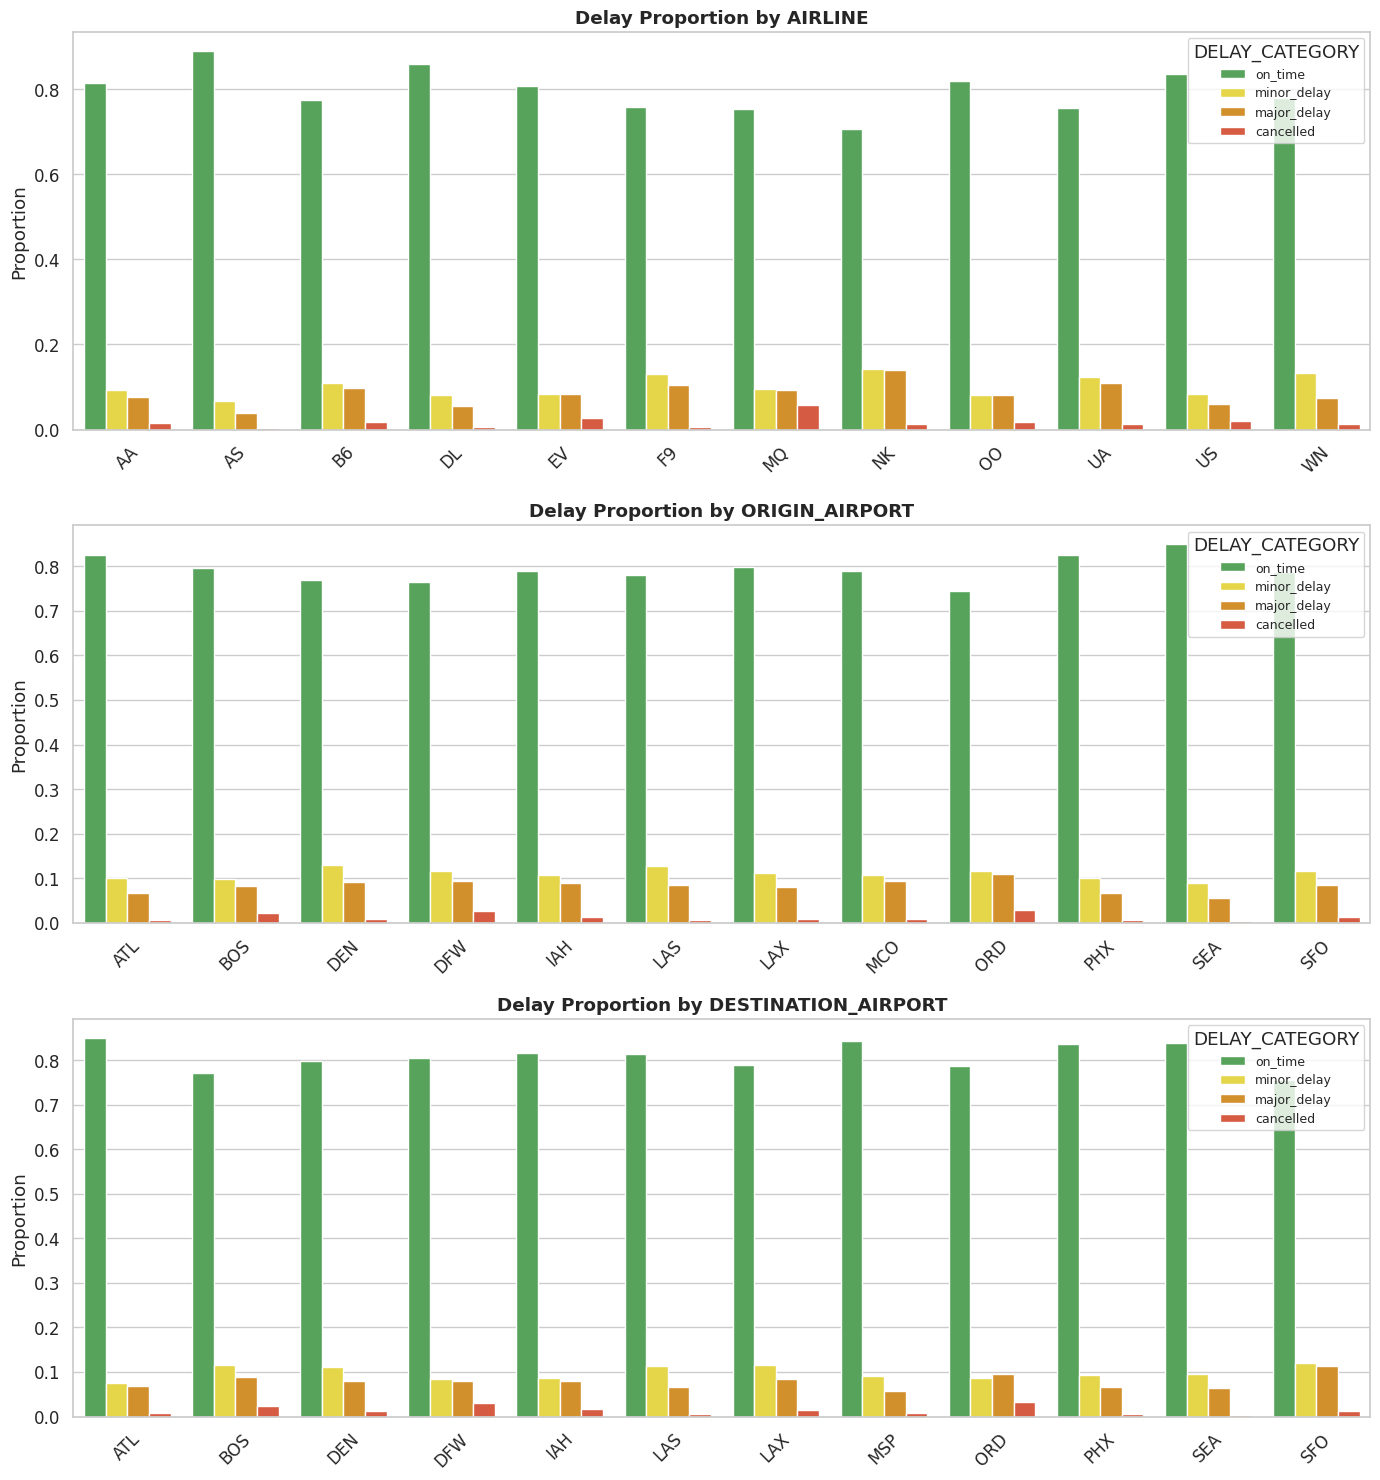

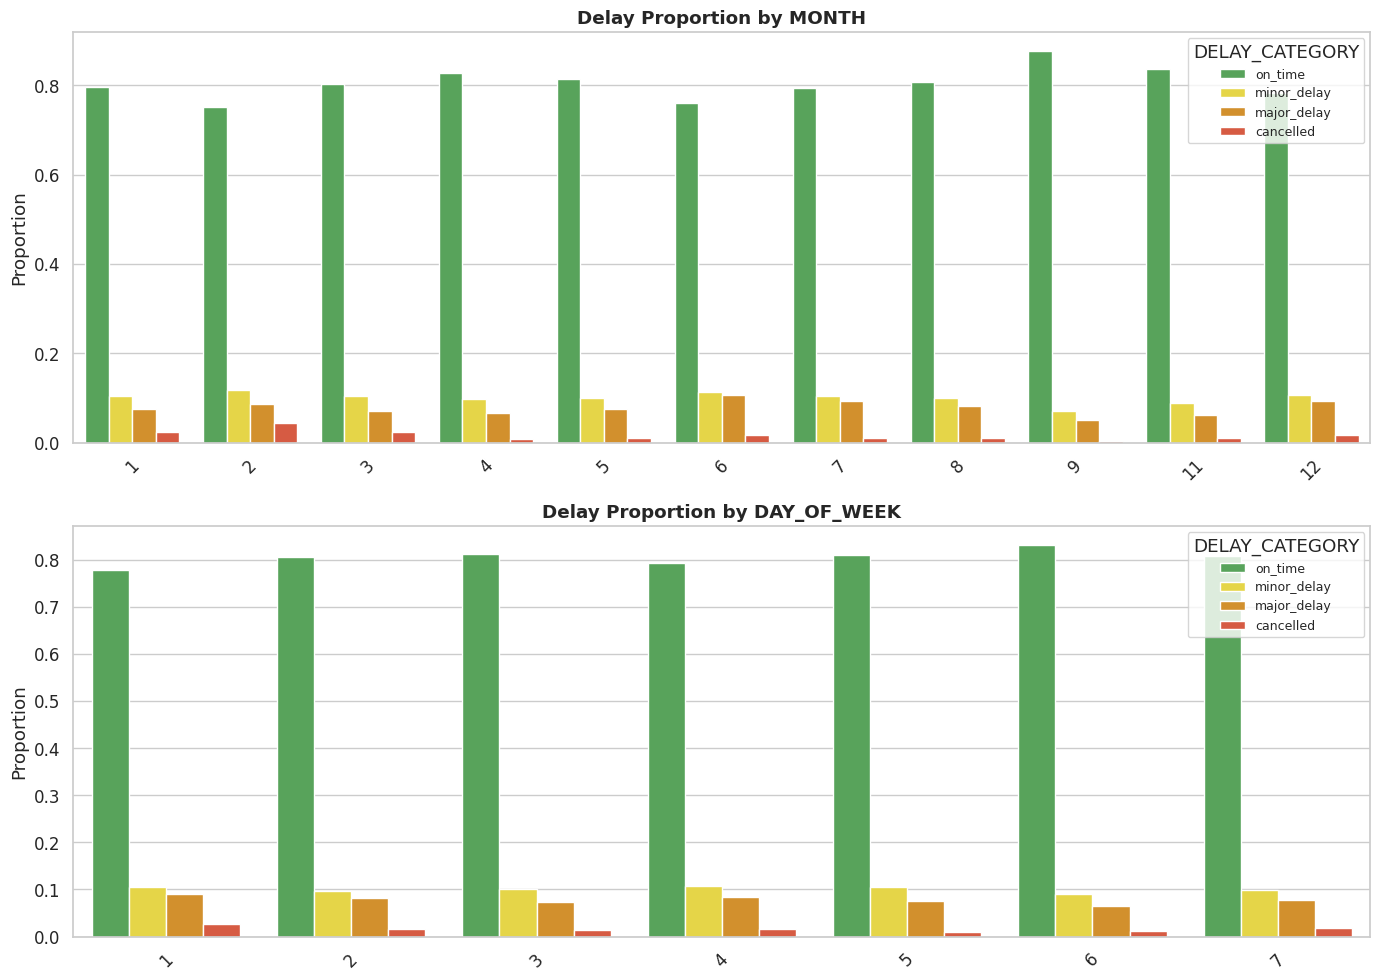

In [ ]:
CAT_BIVAR = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
             "MONTH", "DAY_OF_WEEK"]

plot_cat_proportion(df, CAT_BIVAR, target)

**Interpretation:**
- **Airline:** *NK* and *F9* have a high proportions of major_delay and cancelled, while *DL* and *HA* have the lowest. .
- **Airport:** *EWR* and *ORD* show higher delay/cancellation rates, likely due to congestion.
- **Month:** Winter months (1, 2, 12) and (6, 7) show higher delay/cancellation rates.
- **Day of week:** very slight differences that shows almost nothing.

#### 5c. Delay Rate by Departure Hour

From the Previous observations i think that Departure hour is a very strong temporal signal for delay propagation.

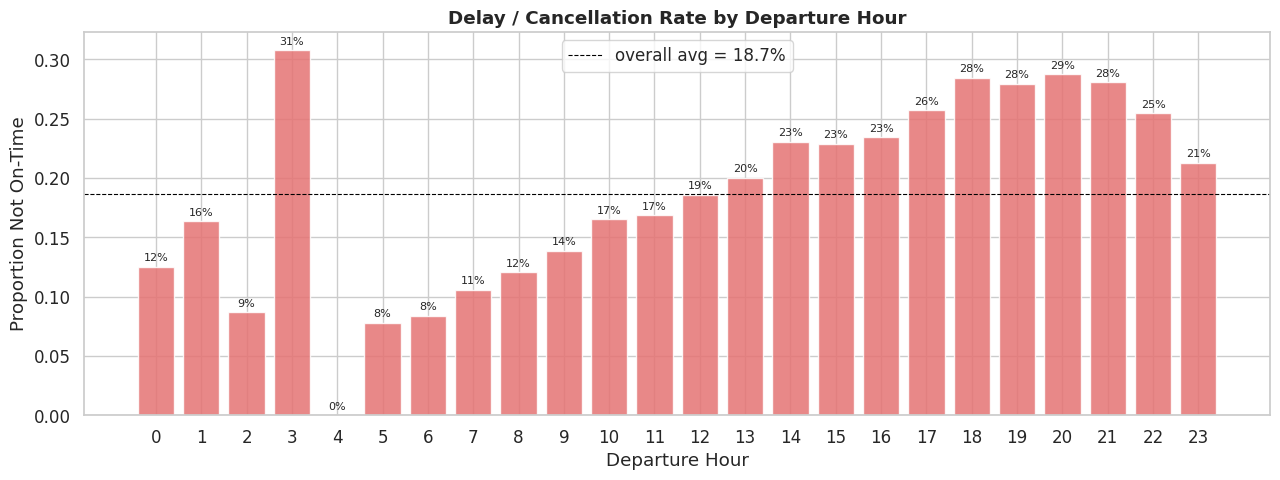

In [ ]:
hour_rate = (
    df.groupby("departure_hour")[target]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=CAT_ORDER)
)
hour_rate["not_on_time"] = 1 - hour_rate["on_time"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(hour_rate.index, hour_rate["not_on_time"], color="#E57373", alpha=0.85) #TODO(style): below average = red, above = green 
ax.set_xlabel("Departure Hour")
ax.set_ylabel("Proportion Not On-Time")
ax.set_title("Delay / Cancellation Rate by Departure Hour", fontweight="bold")
ax.set_xticks(range(24))
for h, r in zip(hour_rate.index, hour_rate["not_on_time"]):
    ax.text(h, r + 0.005, f"{r:.0%}", ha="center", fontsize=8)
ax.axhline(hour_rate["not_on_time"].mean(), color="black",
           linestyle="--", linewidth=0.8, label=f'overall avg = {hour_rate["not_on_time"].mean():.1%}')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- Flights departing between **14:00–22:00** have the highest not-on-time rate -above the average with a good eye-balled threshold-.
- Early-morning departures (05:00–07:00) have the lowest delay rate.
- 03:00 has the heighest not-on-time rate, but looking at the distribution in section 4b, little to no flights depart at this time of day?
- This pattern strongly suggests **departure_hour** as a key predictive feature.

In [ ]:
## TODO: a little search on the 3:00 case, whether this has something to do with anything or on how to interpret it?

### 6. Correlation Analysis

We encode the target ordinally (on_time = 0, minor_delay = 1, major_delay = 2, cancelled = 3)
so it can participate in the Pearson correlation matrix.  

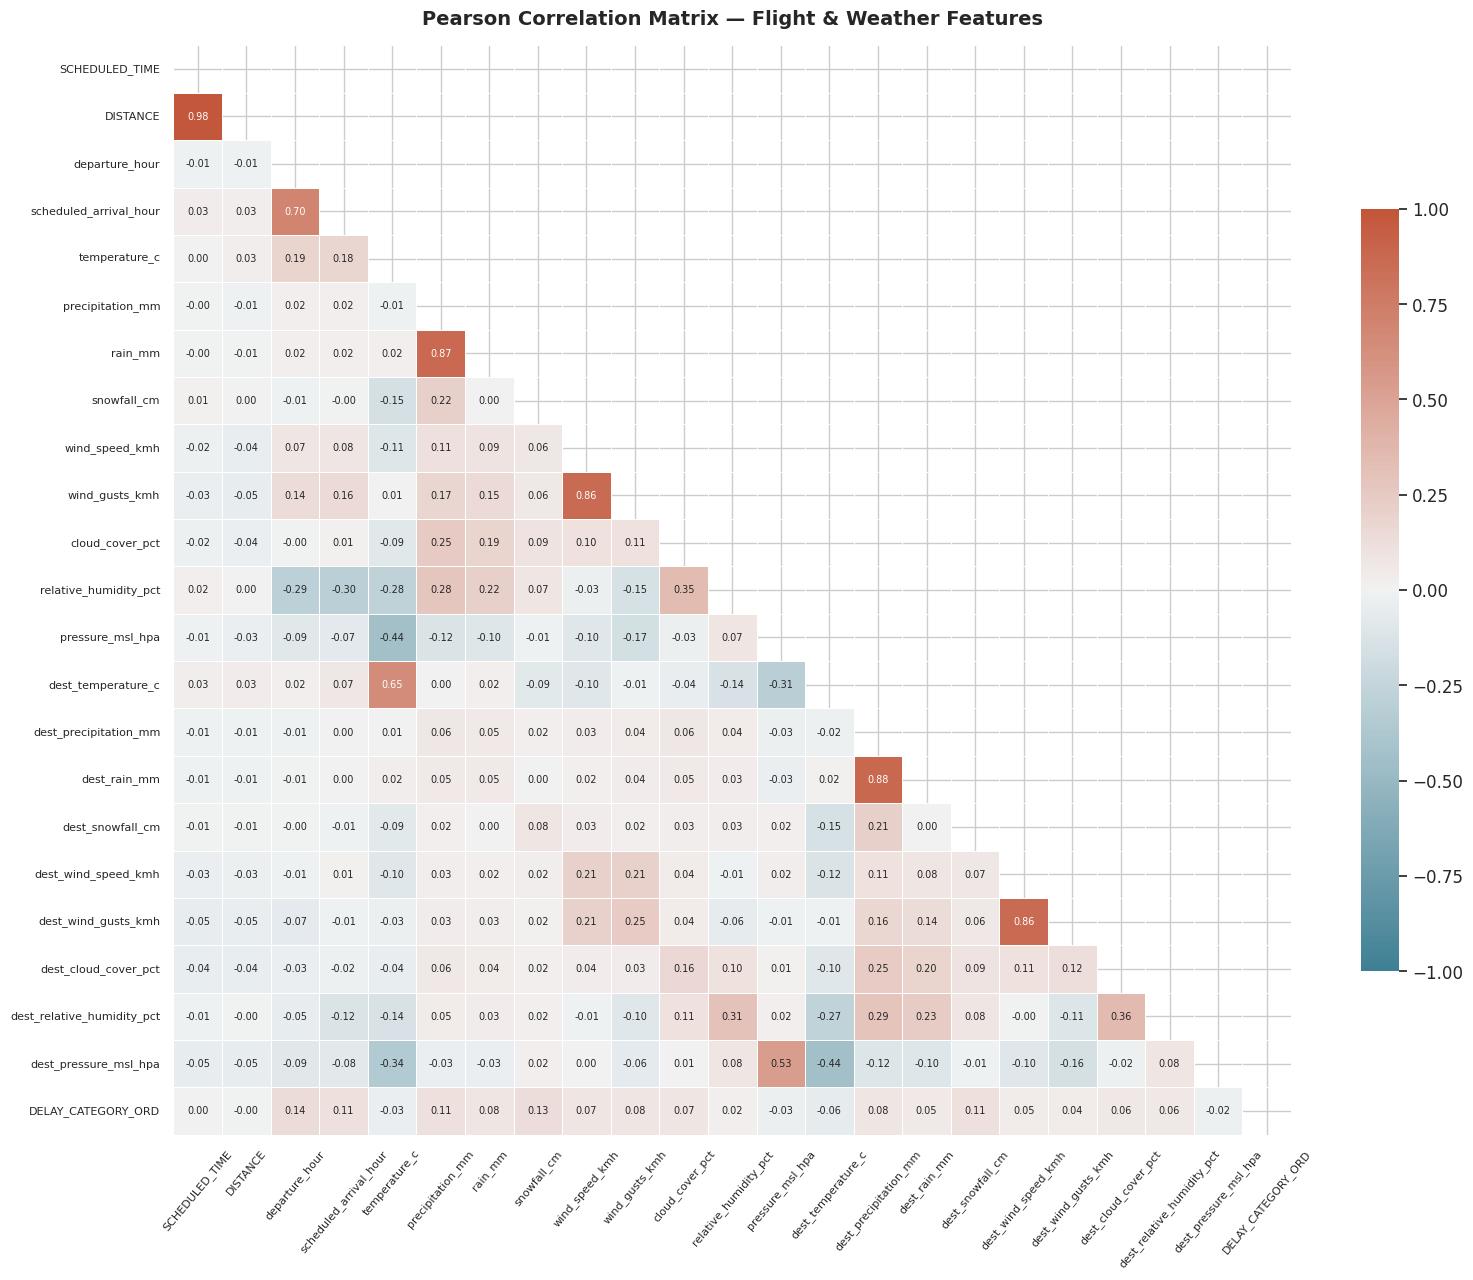

In [ ]:
CORR_FEATURES = [
    "SCHEDULED_TIME", "DISTANCE",
    "departure_hour", "scheduled_arrival_hour",
    "temperature_c", "precipitation_mm", "rain_mm", "snowfall_cm",
    "wind_speed_kmh", "wind_gusts_kmh",
    "cloud_cover_pct", "relative_humidity_pct", "pressure_msl_hpa",
    "dest_temperature_c", "dest_precipitation_mm", "dest_rain_mm",
    "dest_snowfall_cm", "dest_wind_speed_kmh", "dest_wind_gusts_kmh",
    "dest_cloud_cover_pct", "dest_relative_humidity_pct",
    "dest_pressure_msl_hpa",
]

ordinal_map = {"on_time": 0, "minor_delay": 1,
               "major_delay": 2, "cancelled": 3}
df_corr = df[CORR_FEATURES].copy()
df_corr["DELAY_CATEGORY_ORD"] = df[target].map(ordinal_map)

corr = df_corr.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    linewidths=0.4,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Pearson Correlation Matrix — Flight & Weather Features",
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=50, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Strong positive correlations:**
  - `SCHEDULED_TIME` ↔ `DISTANCE` (r ≈ 0.98): near-perfect collinearity.
  - `wind_speed_kmh` ↔ `wind_gusts_kmh` (r ≈ 0.86) and same at destination: wind gust is very highly correlated with wind speed.
  - `temperature_c` ↔ `dest_temperature_c` (r ≈ 0.65): origin and destination temperatures are correlated but this might be just a chance, they have nothing to do with each other, different countries :D
  - `precipitation_mm` ↔ `rain_mm` (r ≈ 0.87): rain is the dominant precipitation type.  

**Findings:**
- **Target correlation:** `DELAY_CATEGORY_ORD` shows very weak linear correlations with all features (|r| < 0.15).
- **Redundancy:** Several feature pairs are highly collinear, So we will need a feature selection method.

### 7. Key Takeaways & Recommendations for Modelling

1. **Class imbalance** (~80:10:8:2) — use `class_weight="balanced"` or SMOTE.
2. **Drop `YEAR`** — constant, no information.
3. **Encode `weather_code` as categorical** — it is a code, not a numeric value.
4. **Consider binary weather flags** (`has_rain`, `has_snow`) — precipitation columns are zero-inflated.
5. **Remove one of `SCHEDULED_TIME` / `DISTANCE`** (r ≈ 0.98) — almost perfect collinearity.
6. **Remove one of `wind_speed_kmh` / `wind_gusts_kmh`** (r ≈ 0.86) — almost perfect collinearity.
7. **Departure hour** is the strongest temporal signal — delay rate increases in (14:00 - 22:00).
8. **Airline** is the strongest categorical predictor — (NK) and (F9) have the highest delay rates.
9. **Non-linear models recommended** — since all target correlations are |r| < 0.15. 
10. **Redundancy:** Several feature pairs are highly collinear, So we will need a feature selection method.
11. **Metric choice:** Macro-averaged F1 or Cohen's kappa — not accuracy.